In [1]:
import os
import glob
import os
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from scipy.stats import pearsonr
from adjustText import adjust_text
from tqdm import tqdm
import time
from collections import Counter
from matplotlib.patches import Patch
from scipy.spatial.distance import cdist
import textwrap
import re
import scipy
from scanpy.tools._utils import get_init_pos_from_paga 
import warnings
import networkx as nx

from scipy.stats import zscore
from matplotlib.colors import LinearSegmentedColormap
from scipy.cluster.hierarchy import linkage, fcluster
import matplotlib.patheffects as pe
from collections import defaultdict

import rmm
import cupy
import cudf
import cupy as cp
# import cvxpy as cpv
from sklearn.manifold import MDS
from cuml.metrics import pairwise_distances
from cuml.metrics import nan_euclidean_distances
from rmm.allocators.cupy import rmm_cupy_allocator
from sklearn.feature_extraction.text import CountVectorizer
from cuml.linear_model import ElasticNet
import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

# Load genes

In [2]:
%%time
fpath = "../resources/gene_names.tsv.gz"
gdf = pd.read_csv(fpath, sep='\t', low_memory=False)
print(f"{gdf.shape=}")

protein_coding = gdf[gdf['Gene type'] == 'protein_coding']['Gene name'].unique()
print(f"N protein coding: {protein_coding.shape=}")

gdf.shape=(73466, 8)
N protein coding: protein_coding.shape=(18149,)
CPU times: user 123 ms, sys: 22.9 ms, total: 146 ms
Wall time: 150 ms


# Load data

In [3]:
%%time

# Load and aggregate pseudotime data
fpath = "/scratch/indikar_root/indikar1/shared_data/hematokytos/new_processed/three_libraries_new.h5ad"
sdata = sc.read_h5ad(fpath)

sdata.X = sdata.layers['raw_counts'].copy()
sdata.obs['cell_type'] = sdata.obs['label'].copy()
sdata = sdata[sdata.obs['cell_type'].notna()].copy()
sdata = sc.get.aggregate(sdata, by='cell_type', func='sum')
sdata.X = sdata.layers['sum']
sdata.obs['group'] = 'sample'

# Load and preprocess reference data
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/cell_type_ref.h5ad"
rdata = sc.read_h5ad(fpath)
rdata.obs['group'] = 'atlas'

# Concatenate and return
adata = an.concat([sdata, rdata], join='outer', axis=0)
adata

CPU times: user 3.09 s, sys: 5.14 s, total: 8.23 s
Wall time: 1min 52s


AnnData object with n_obs × n_vars = 199 × 36429
    obs: 'cell_type', 'group'
    layers: 'sum'

In [4]:
adata.obs['group'].value_counts(dropna=False)

group
atlas     188
sample     11
Name: count, dtype: int64

In [5]:
def load_label_map_at_level(file_path: str, level: str) -> dict:
    """Reads YAML, mapping labels to a specific level, with a fallback."""
    with open(file_path, 'r') as f:
        full_data = yaml.safe_load(f)

    label_map = {}
    for label, data in full_data.items():
        if not isinstance(data, dict):
            continue
        
        # Use the requested level's value if it exists.
        value = data.get(level)

        # If it doesn't exist, find the highest available level and use its value.
        if value is None:
            # max() on ['level1', 'level2'] correctly returns 'level2'.
            # The default prevents an error if no 'level' keys are found.
            highest_level_key = max([k for k in data if str(k).startswith('level')], default=None)
            if highest_level_key:
                value = data.get(highest_level_key)
        
        # Only add entries that have a valid level annotation.
        if value is not None:
            label_map[label] = value
            
    return label_map
    

fpath = "../resources/cell_labels.yaml"

levels = ['level1', 'level2', 'level3', 'level4']
label_maps = {}
for label in levels:
    label_map = load_label_map_at_level(fpath, label)
    adata.obs[label] = adata.obs['cell_type'].map(label_map)
    adata.obs[label] = np.where(adata.obs[label].isna(), adata.obs['cell_type'], adata.obs[label])
    print(f"{label} {adata.obs[label].nunique()} labels")
    label_maps[label] = label_map

adata

level1 13 labels
level2 19 labels
level3 45 labels
level4 78 labels


AnnData object with n_obs × n_vars = 199 × 36429
    obs: 'cell_type', 'group', 'level1', 'level2', 'level3', 'level4'
    layers: 'sum'

In [6]:
adata.obs.head()

,cell_type,group,level1,level2,level3,level4
CLP,CLP,sample,CLP,CLP,CLP,CLP
CMP,CMP,sample,CMP,CMP,CMP,CMP
GMP,GMP,sample,GMP,GMP,GMP,GMP
HSC,HSC,sample,HSC,HSC,HSC,HSC
LMPP,LMPP,sample,LMPP,LMPP,LMPP,LMPP


# Score cell cycle

In [7]:
%%time
regev_genes = [x.strip() for x in open('../resources/regev_lab_cell_cycle_genes.txt')]
s_genes = regev_genes[:43]
g2m_genes = regev_genes[43:]

sc.tl.score_genes_cell_cycle(
    adata,
    s_genes=s_genes,
    g2m_genes=g2m_genes,
)

adata.obs.head()

CPU times: user 129 ms, sys: 40.4 ms, total: 169 ms
Wall time: 179 ms


,cell_type,group,level1,level2,level3,level4,S_score,G2M_score,phase
CLP,CLP,sample,CLP,CLP,CLP,CLP,-88.737573,102.719446,G2M
CMP,CMP,sample,CMP,CMP,CMP,CMP,179.947358,1773.174574,G2M
GMP,GMP,sample,GMP,GMP,GMP,GMP,-24.685780,-3.364308,G1
HSC,HSC,sample,HSC,HSC,HSC,HSC,-1680.206001,-1088.084456,G1
LMPP,LMPP,sample,LMPP,LMPP,LMPP,LMPP,-353.224984,-198.121655,G1


In [11]:
adata.obs['level1'].value_counts()

level1
Hematopoietic    131
Stromal           57
GMP                1
CMP                1
CLP                1
LMPP               1
HSC                1
MEG-ERY            1
MPP                1
R2                 1
R1                 1
initial            1
R3                 1
Name: count, dtype: int64

# Gene filtering 

In [8]:
rsc.get.anndata_to_CPU(adata)
X = adata.X

if sp.issparse(X):
    # replace NaNs in the nonzero entries
    X.data = np.nan_to_num(X.data, nan=0)
    adata.X = X
else:
    # dense array
    adata.X = np.nan_to_num(X, nan=0)

adata.X = adata.X.astype(int)
print(f"{adata.X.shape=}")
print(f"{type(adata.X)=}")

adata

adata.X.shape=(199, 36429)
type(adata.X)=<class 'numpy.ndarray'>


AnnData object with n_obs × n_vars = 199 × 36429
    obs: 'cell_type', 'group', 'level1', 'level2', 'level3', 'level4', 'S_score', 'G2M_score', 'phase'
    layers: 'sum'

In [12]:
rsc.get.anndata_to_GPU(adata)

adata.var['filter_pass'] = True # set the gene filter

# pt genes only
adata.var['filter_pass'] = np.where(~adata.var.index.isin(protein_coding), False, adata.var['filter_pass'])

# disallow GO cell cycle genes
fpath = "../resources/human_cell_cycle_genes.csv"
cdf = pd.read_csv(fpath)
adata.var['filter_pass'] = np.where(adata.var.index.isin(cdf['gene_name'].unique()), False, adata.var['filter_pass'])

# disallow Regev cell cycle genes
fpath = "../resources/regev_lab_cell_cycle_genes.txt"
genes = [x.strip() for x in open(fpath)]
adata.var['filter_pass'] = np.where(adata.var.index.isin(genes), False, adata.var['filter_pass'])

# disallow mitochondrial and ribosomal genes
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('MT'), False, adata.var['filter_pass'])
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('RP'), False, adata.var['filter_pass'])

rsc.get.anndata_to_CPU(adata)
print(adata.var['filter_pass'].value_counts().to_string())

filter_pass
False    20261
True     16168


# scvi

INFO: GPU available: True (cuda), used: True
2025-12-17 12:04:11 | [INFO] GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2025-12-17 12:04:11 | [INFO] TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
2025-12-17 12:04:11 | [INFO] HPU available: False, using: 0 HPUs
INFO: You are using a CUDA device ('NVIDIA A100 80GB PCIe MIG 3g.40gb') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
2025-12-17 12:04:11 | [INFO] You are using a CUDA device ('NVIDIA A100 80GB PCIe MIG 3g.40gb') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, re

Training:   0%|          | 0/500 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 5 records. Best score: 9095.109. Signaling Trainer to stop.


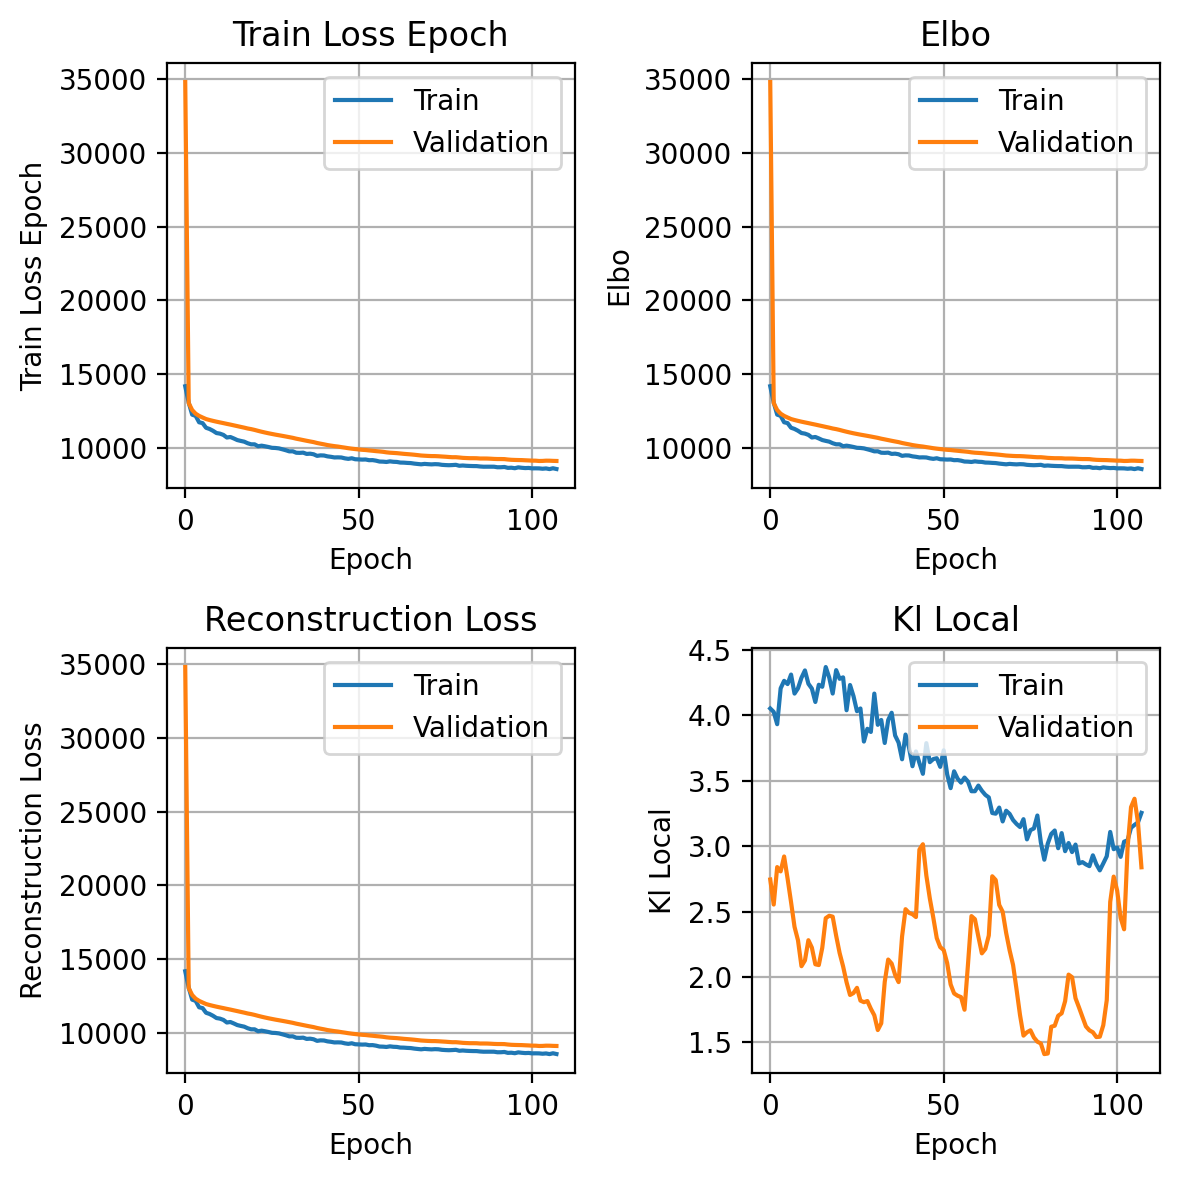

CPU times: user 9.47 s, sys: 392 ms, total: 9.86 s
Wall time: 12.5 s


In [13]:
%%time
batch_key = "group"

rsc.get.anndata_to_CPU(adata)
bdata = adata.copy()
bdata = bdata[:, bdata.var['filter_pass']].copy()

rsc.get.anndata_to_GPU(bdata)
rsc.pp.highly_variable_genes(
    bdata,
    flavor="seurat_v3",
    n_top_genes=2500,
    batch_key=batch_key,
)

bdata = bdata[:, bdata.var['highly_variable']].copy()
rsc.get.anndata_to_CPU(bdata)

# scvi
scvi.model.SCVI.setup_anndata(
    bdata, 
    batch_key=batch_key,
    continuous_covariate_keys=['S_score', 'G2M_score'],
)

model = scvi.model.SCVI(
    bdata,
    n_hidden=128,
    n_latent=24,
    n_layers=2, 
    dropout_rate=0.25,
    dispersion='gene-cell',
    gene_likelihood='zinb',
)

model.train(
    max_epochs=500,
    accelerator='gpu',
    early_stopping_patience=5,
    early_stopping=True,
    batch_size=25,
    train_size=0.9,
    plan_kwargs={"lr": 1e-4},
)

history = model.history

metrics = [
    ("train_loss_epoch", "validation_loss"),
    ("elbo_train", "elbo_validation"),
    ("reconstruction_loss_train", "reconstruction_loss_validation"),
    ("kl_local_train", "kl_local_validation"),
]

plt.rcParams['figure.dpi'] = 200
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
axes = axes.flatten()

for i, (train_key, val_key) in enumerate(metrics):
    ax = axes[i]
    train_df = history[train_key]
    val_df = history[val_key]

    ax.plot(train_df.index, train_df[train_key], label='Train')
    ax.plot(val_df.index, val_df[val_key], label='Validation')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(train_key.replace('_train', '').replace('_', ' ').title())
    ax.set_title(train_key.replace('_train', '').replace('_', ' ').title())
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

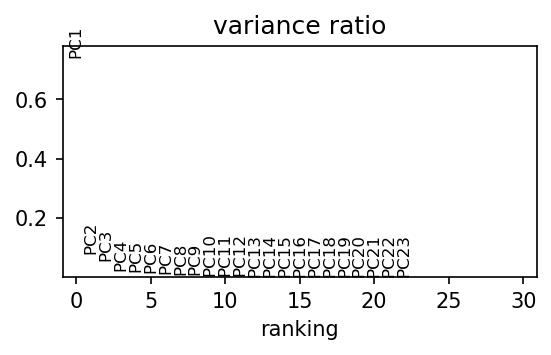

CPU times: user 119 ms, sys: 38.9 ms, total: 158 ms
Wall time: 296 ms


In [14]:
%%time 

embed = model.get_latent_representation()
embed = sc.AnnData(embed, obs=adata.obs)

rsc.get.anndata_to_GPU(embed)
rsc.pp.pca(embed)

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 2
sc.pl.pca_variance_ratio(embed)

In [34]:
# regroup BM data in level 3 
mapping = {
    'HSC': 'target',
    'CLP': 'progenitors', 
    'LMPP': 'progenitors', 
    'MPP': 'progenitors',
    'CMP': 'progenitors',
    'GMP': 'progenitors',
    'MEG-ERY': 'progenitors',
    # 'R1': 'reprogram', 'R2': 'reprogram', 'R3': 'reprogram'
}

embed.obs['level3_new'] = embed.obs['level3'].replace(mapping)

/tmp/ipykernel_3426724/2524727119.py:13: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  embed.obs['level3_new'] = embed.obs['level3'].replace(mapping)


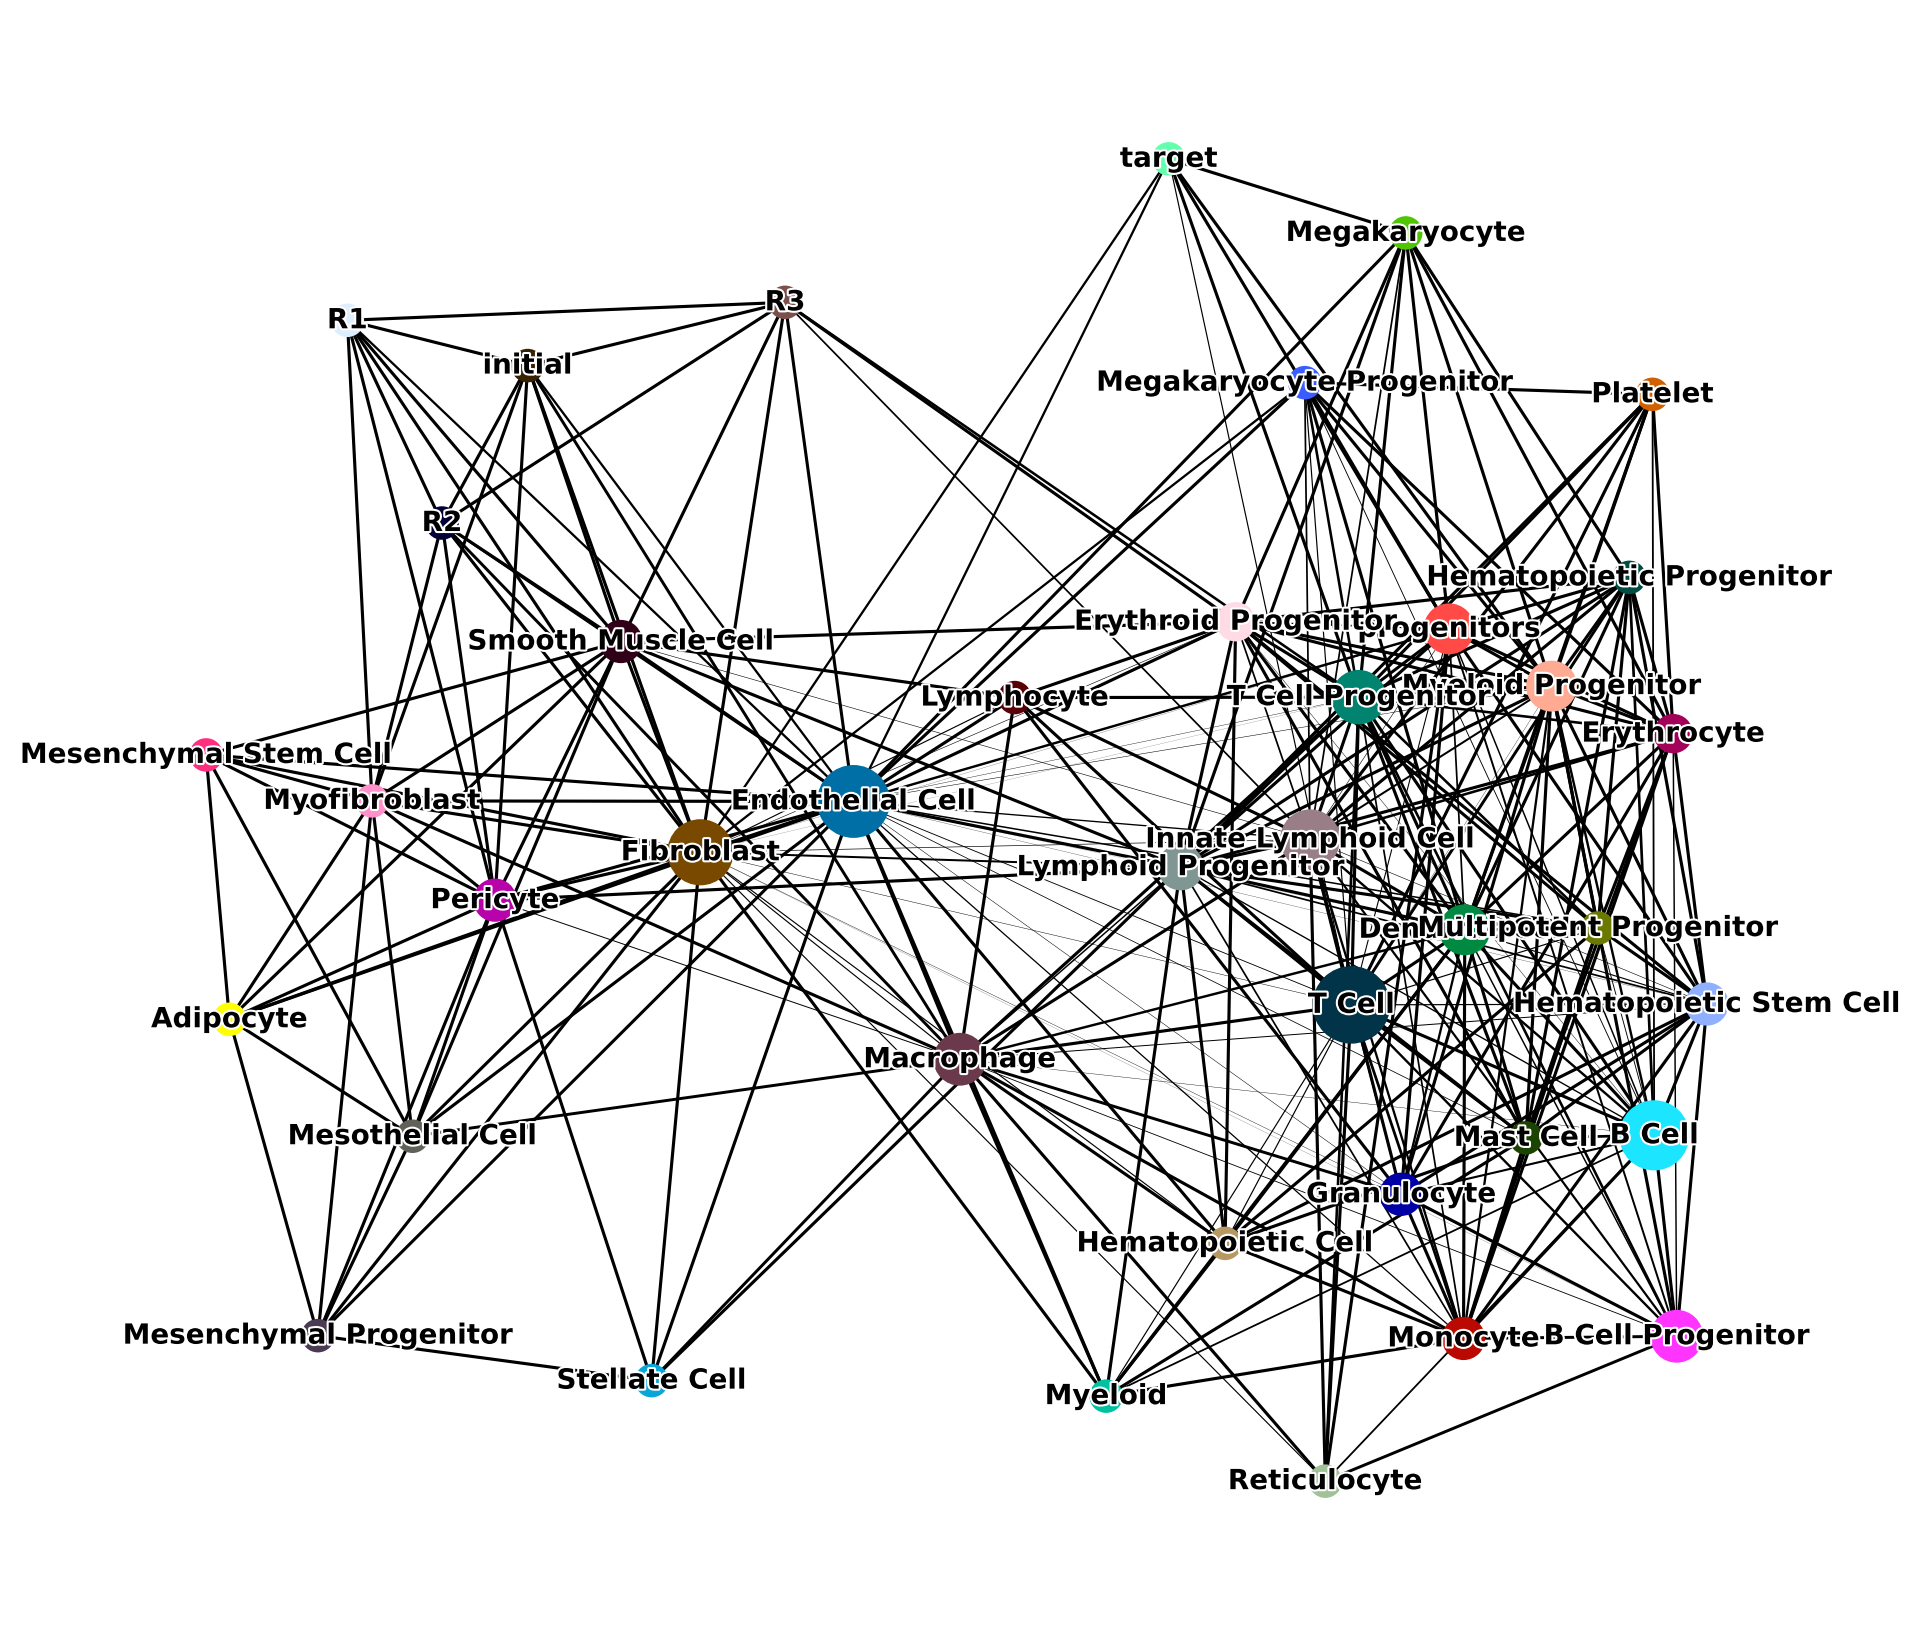

CPU times: user 396 ms, sys: 4.96 ms, total: 401 ms
Wall time: 414 ms


In [35]:
%%time
n_neighbors = 15
# paga_group_column = "level3"
paga_group_column = "level3_new"
n_pcs = 50

rsc.pp.neighbors(
    embed, 
    n_pcs=n_pcs, 
    n_neighbors=n_neighbors,
)

# plot the embedding
sc.tl.paga(embed, groups=paga_group_column)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 10, 10
sc.pl.paga(
    embed, 
    fontoutline=1.5, 
    edge_width_scale=0.15,  
    frameon=False,          
)

embed.obsm['X_paga'] = get_init_pos_from_paga(embed)

Graph with 40 nodes and 298 edges


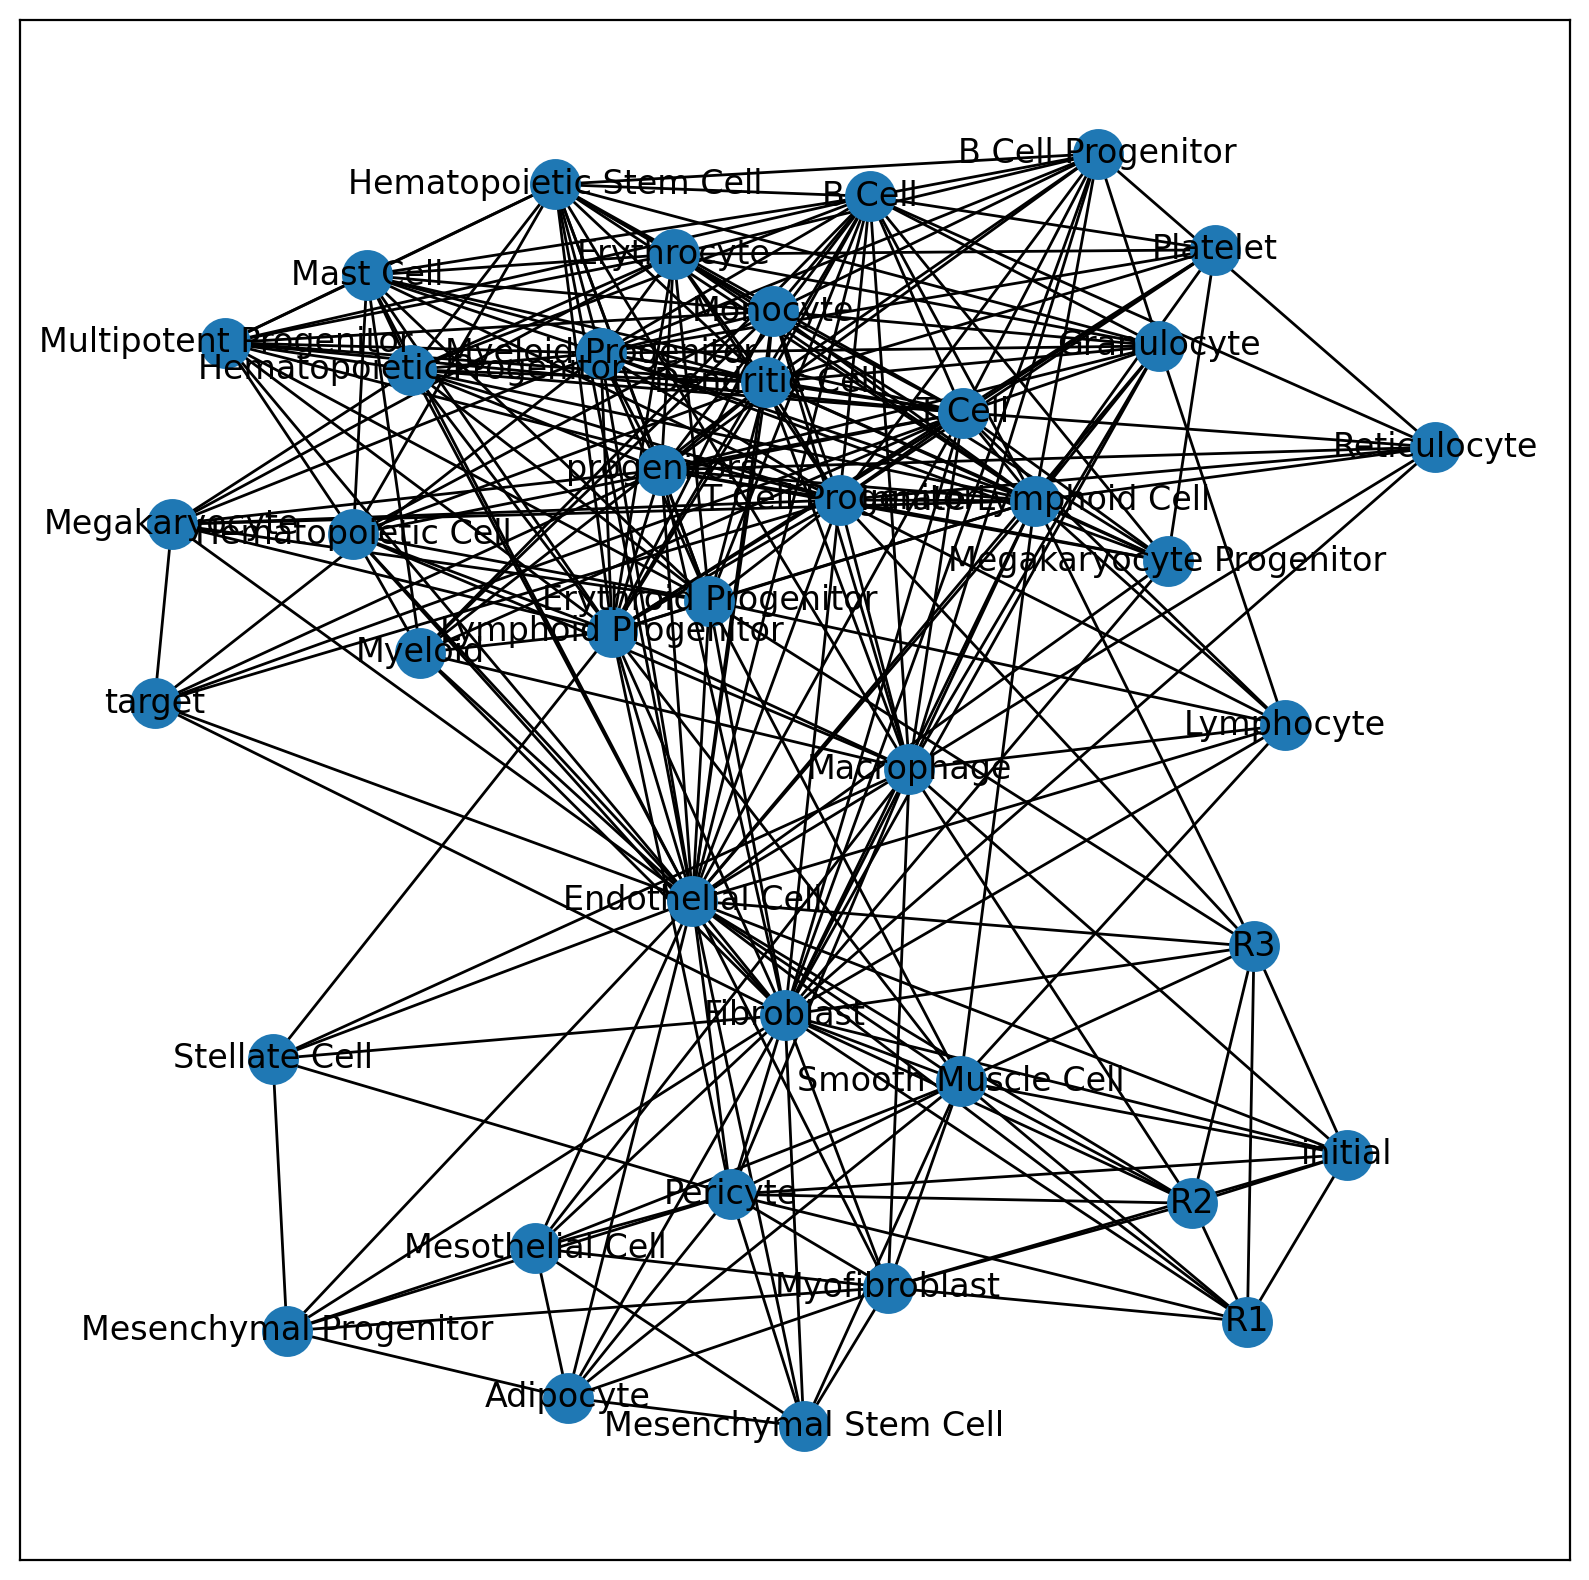

In [36]:
def paga_to_networkx(adata):
    """
    Build a NetworkX graph from adata.uns['paga'].
    
        
    Returns
    -------
    G : networkx.Graph
        Weighted undirected graph (nodes = clusters, edges = PAGA connectivity).
    """
    # Get PAGA connectivity and cluster names
    conn = adata.uns['paga']['connectivities']
    group_key = adata.uns['paga']['groups']
    clusters = adata.obs[group_key].cat.categories

    matrix = pd.DataFrame(
        adata.uns['paga']['connectivities'].todense().copy(),
        index=clusters.values,
        columns=clusters.values,
    )

    G = nx.from_pandas_adjacency(matrix)
    G.pos = adata.uns['paga']['pos'].copy()
    return G

G = paga_to_networkx(embed)
print(G)
nx.draw_networkx(G)

In [37]:
print(list(embed.obs[paga_group_column].unique()))

['progenitors', 'target', 'R1', 'R2', 'R3', 'initial', 'B Cell', 'Dendritic Cell', 'T Cell', 'T Cell Progenitor', 'Innate Lymphoid Cell', 'Hematopoietic Stem Cell', 'Lymphoid Progenitor', 'Adipocyte', 'Macrophage', 'Fibroblast', 'Granulocyte', 'Myeloid Progenitor', 'Endothelial Cell', 'Smooth Muscle Cell', 'Monocyte', 'Erythroid Progenitor', 'Erythrocyte', 'Mesenchymal Progenitor', 'B Cell Progenitor', 'Hematopoietic Cell', 'Multipotent Progenitor', 'Hematopoietic Progenitor', 'Stellate Cell', 'Pericyte', 'Lymphocyte', 'Mast Cell', 'Megakaryocyte', 'Megakaryocyte Progenitor', 'Mesenchymal Stem Cell', 'Mesothelial Cell', 'Myeloid', 'Myofibroblast', 'Platelet', 'Reticulocyte']


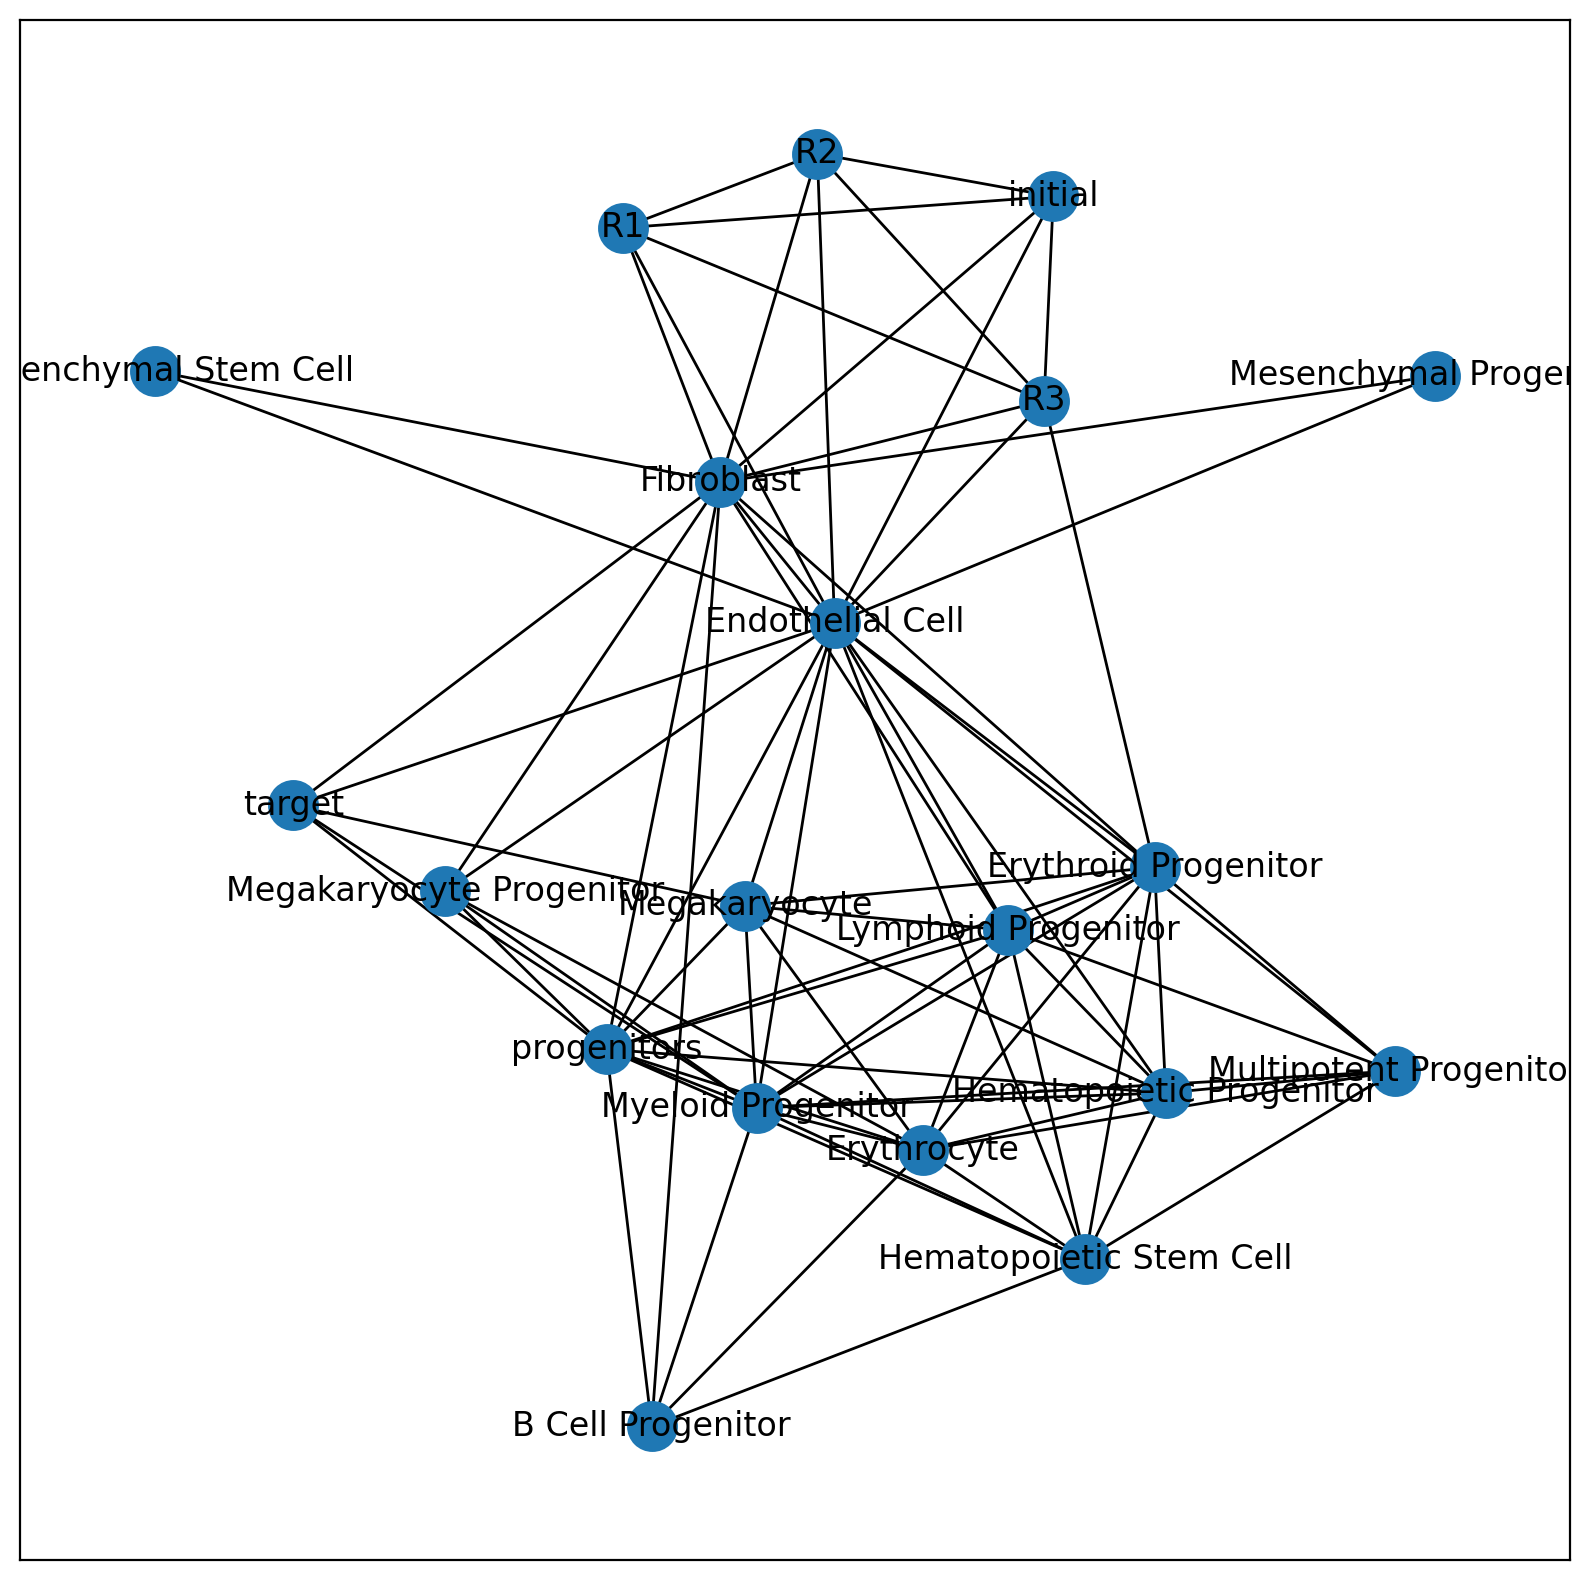

In [38]:
keep = [
    # 'CLP', 'CMP', 'GMP', 'HSC', 'LMPP', 'MEG-ERY', 'MPP', 
    'target', 'progenitors',
    'R1', 'R2', 'R3', 'initial',
    'Hematopoietic Stem Cell',
    'Lymphoid Progenitor',
    'Fibroblast',
    'Myeloid Progenitor',
    'Endothelial Cell',
    # 'Smooth Muscle Cell',
    'Erythroid Progenitor',
    'Erythrocyte',
    'Mesenchymal Progenitor',
    'B Cell Progenitor',
    'Multipotent Progenitor',
    'Hematopoietic Progenitor',
    'Megakaryocyte',
    'Megakaryocyte Progenitor',
    'Mesenchymal Stem Cell',
]

G.remove_nodes_from([n for n in G.nodes() if n not in keep])
nx.draw_networkx(G)

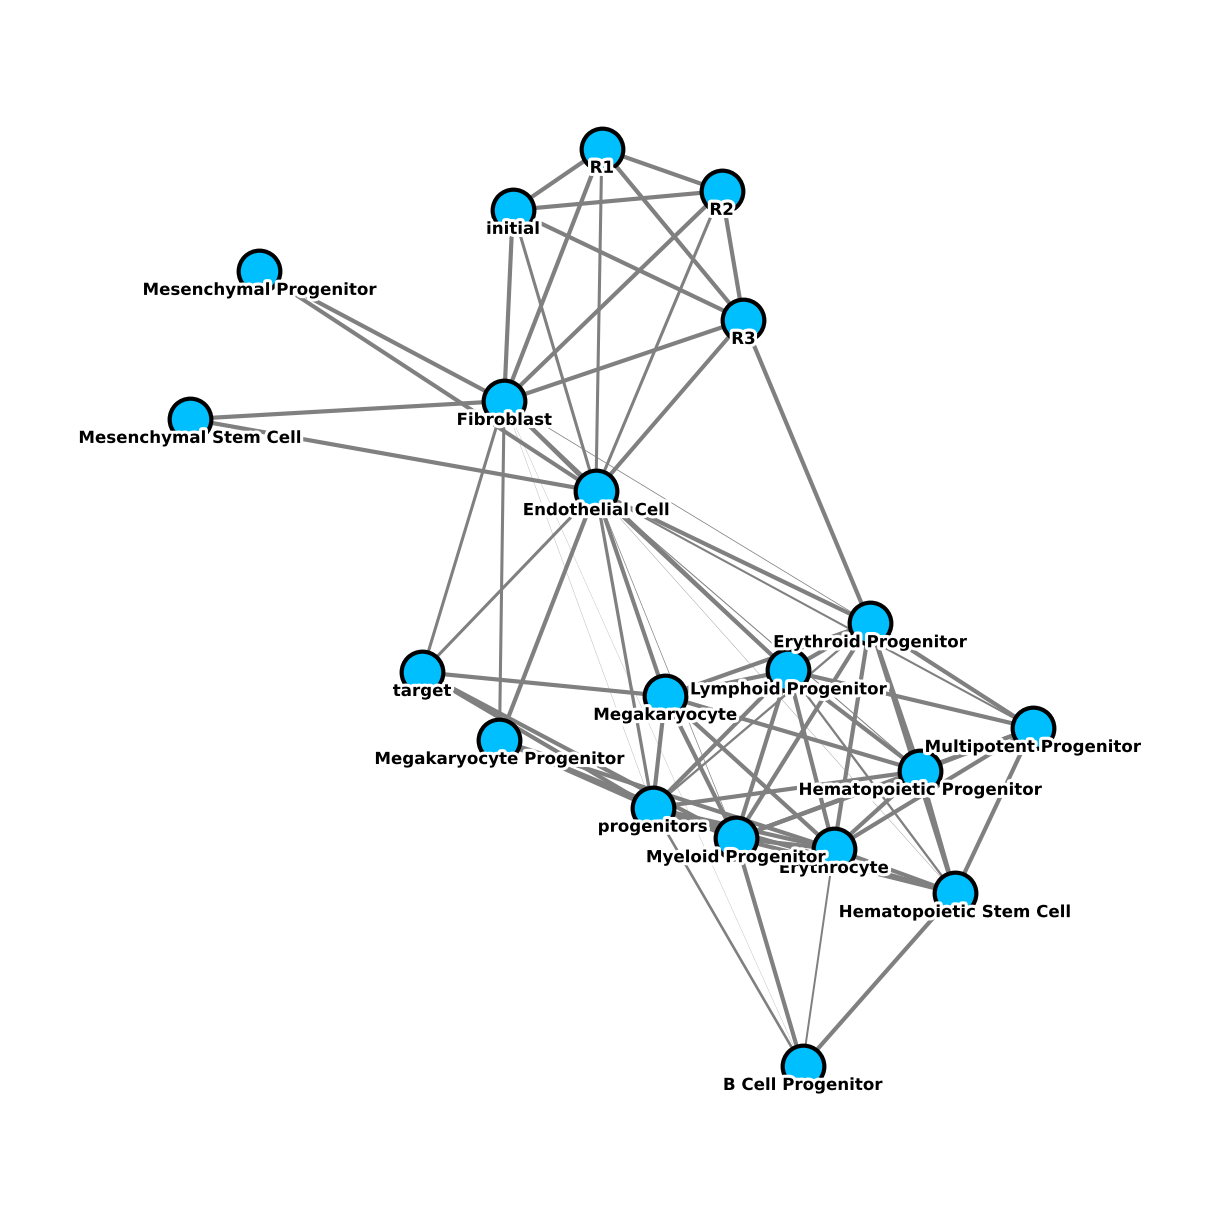

In [44]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 5, 5

# Plot
pos = nx.spring_layout(G, seed=2)
edges, weights = zip(*nx.get_edge_attributes(G, 'weight').items())

nx.draw_networkx_edges(
    G, 
    pos,
    edgelist=edges,
    edge_color='grey',
    width=np.array(weights),
)
nx.draw_networkx_nodes(
    G, pos, 
    node_color='deepskyblue', 
    node_size=100, 
    edgecolors='black',   
    linewidths=1
)

# Draw labels with white border (stroke)
# label_dict = {n: n.lower().replace("_", " ") for n in G.nodes}
label_dict = {n: n.replace("_", " ") for n in G.nodes}
# how much to shift down in layout‐units:
y_off = 0.025

# build new label positions
label_pos = {n: (x, y - y_off) for n, (x, y) in pos.items()}

# then draw labels at the shifted locations
labels = nx.draw_networkx_labels(
    G,
    label_pos,
    labels=label_dict,
    font_size=4,
    font_weight='bold',
    verticalalignment='top'  # keep the text anchored at its top
)

for _, t in labels.items():
    t.set_path_effects([
        pe.Stroke(linewidth=1.5, foreground='white'),
        pe.Normal()
    ])

plt.axis('off')
xs, ys = zip(*pos.values())
pad = 0.25
ax = plt.gca()
ax.set_xlim(min(xs)-pad, max(xs)+pad)
ax.set_ylim(min(ys)-pad, max(ys)+pad)
ax.set_facecolor('none')    # axes background
plt.gcf().set_facecolor('none')    # figure background
plt.show()

# Distance matrix 

In [45]:
%%time
X = embed.obsm['X_pca']
print(f"{X.shape=}")

dists = pairwise_distances(X, metric='euclidean')
print(f"{dists.shape=}")

# df = pd.DataFrame(
#     dists, 
#     index=embed.obs['level3'].values,
#     columns=embed.obs['level3'].values,
# )

df = pd.DataFrame(
    dists, 
    index=embed.obs['level3_new'].values,
    columns=embed.obs['level3_new'].values,
)

df = df.groupby(level=0, axis=0).mean().groupby(level=0, axis=1).mean()
df = df[keep].loc[keep]
df = (df - df.values.min()) / (df.values.max() - df.values.min())
# df.index = df.index.str.lower().str.replace("_", " ")
# df.columns = df.columns.str.lower().str.replace("_", " ")
print(f"{df.shape=}")

df.head()

X.shape=(199, 23)
dists.shape=(199, 199)
df.shape=(20, 20)
CPU times: user 5.9 ms, sys: 0 ns, total: 5.9 ms
Wall time: 5.94 ms


<timed exec>:19: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
<timed exec>:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
<timed exec>:19: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.


,target,progenitors,R1,R2,R3,initial,Hematopoietic Stem Cell,Lymphoid Progenitor,Fibroblast,Myeloid Progenitor,Endothelial Cell,Erythroid Progenitor,Erythrocyte,Mesenchymal Progenitor,B Cell Progenitor,Multipotent Progenitor,Hematopoietic Progenitor,Megakaryocyte,Megakaryocyte Progenitor,Mesenchymal Stem Cell
target,0.000000,0.182775,0.500066,0.537880,0.360001,0.556522,0.376649,0.322707,0.523655,0.308055,0.414276,0.286631,0.299014,0.732194,0.373571,0.344444,0.232670,0.217326,0.237985,0.666519
progenitors,0.182775,0.177016,0.593039,0.631548,0.445584,0.657751,0.344877,0.363955,0.615357,0.291873,0.493281,0.381047,0.308929,0.840926,0.282140,0.443168,0.336896,0.267242,0.225013,0.781486
R1,0.500066,0.593039,0.000000,0.061472,0.219794,0.179171,0.661136,0.506233,0.441685,0.646052,0.456117,0.427792,0.569997,0.462868,0.726196,0.463717,0.481482,0.516497,0.572115,0.510212
R2,0.537880,0.631548,0.061472,0.000000,0.268644,0.156296,0.694415,0.544789,0.465974,0.684618,0.487543,0.461177,0.606596,0.472134,0.762843,0.488143,0.519176,0.555123,0.618628,0.518880
R3,0.360001,0.445584,0.219794,0.268644,0.000000,0.336416,0.540150,0.380883,0.411303,0.493039,0.367949,0.303866,0.421180,0.519085,0.584258,0.373630,0.348565,0.344082,0.392843,0.544196


Text(220.16666666666663, 0.5, '')

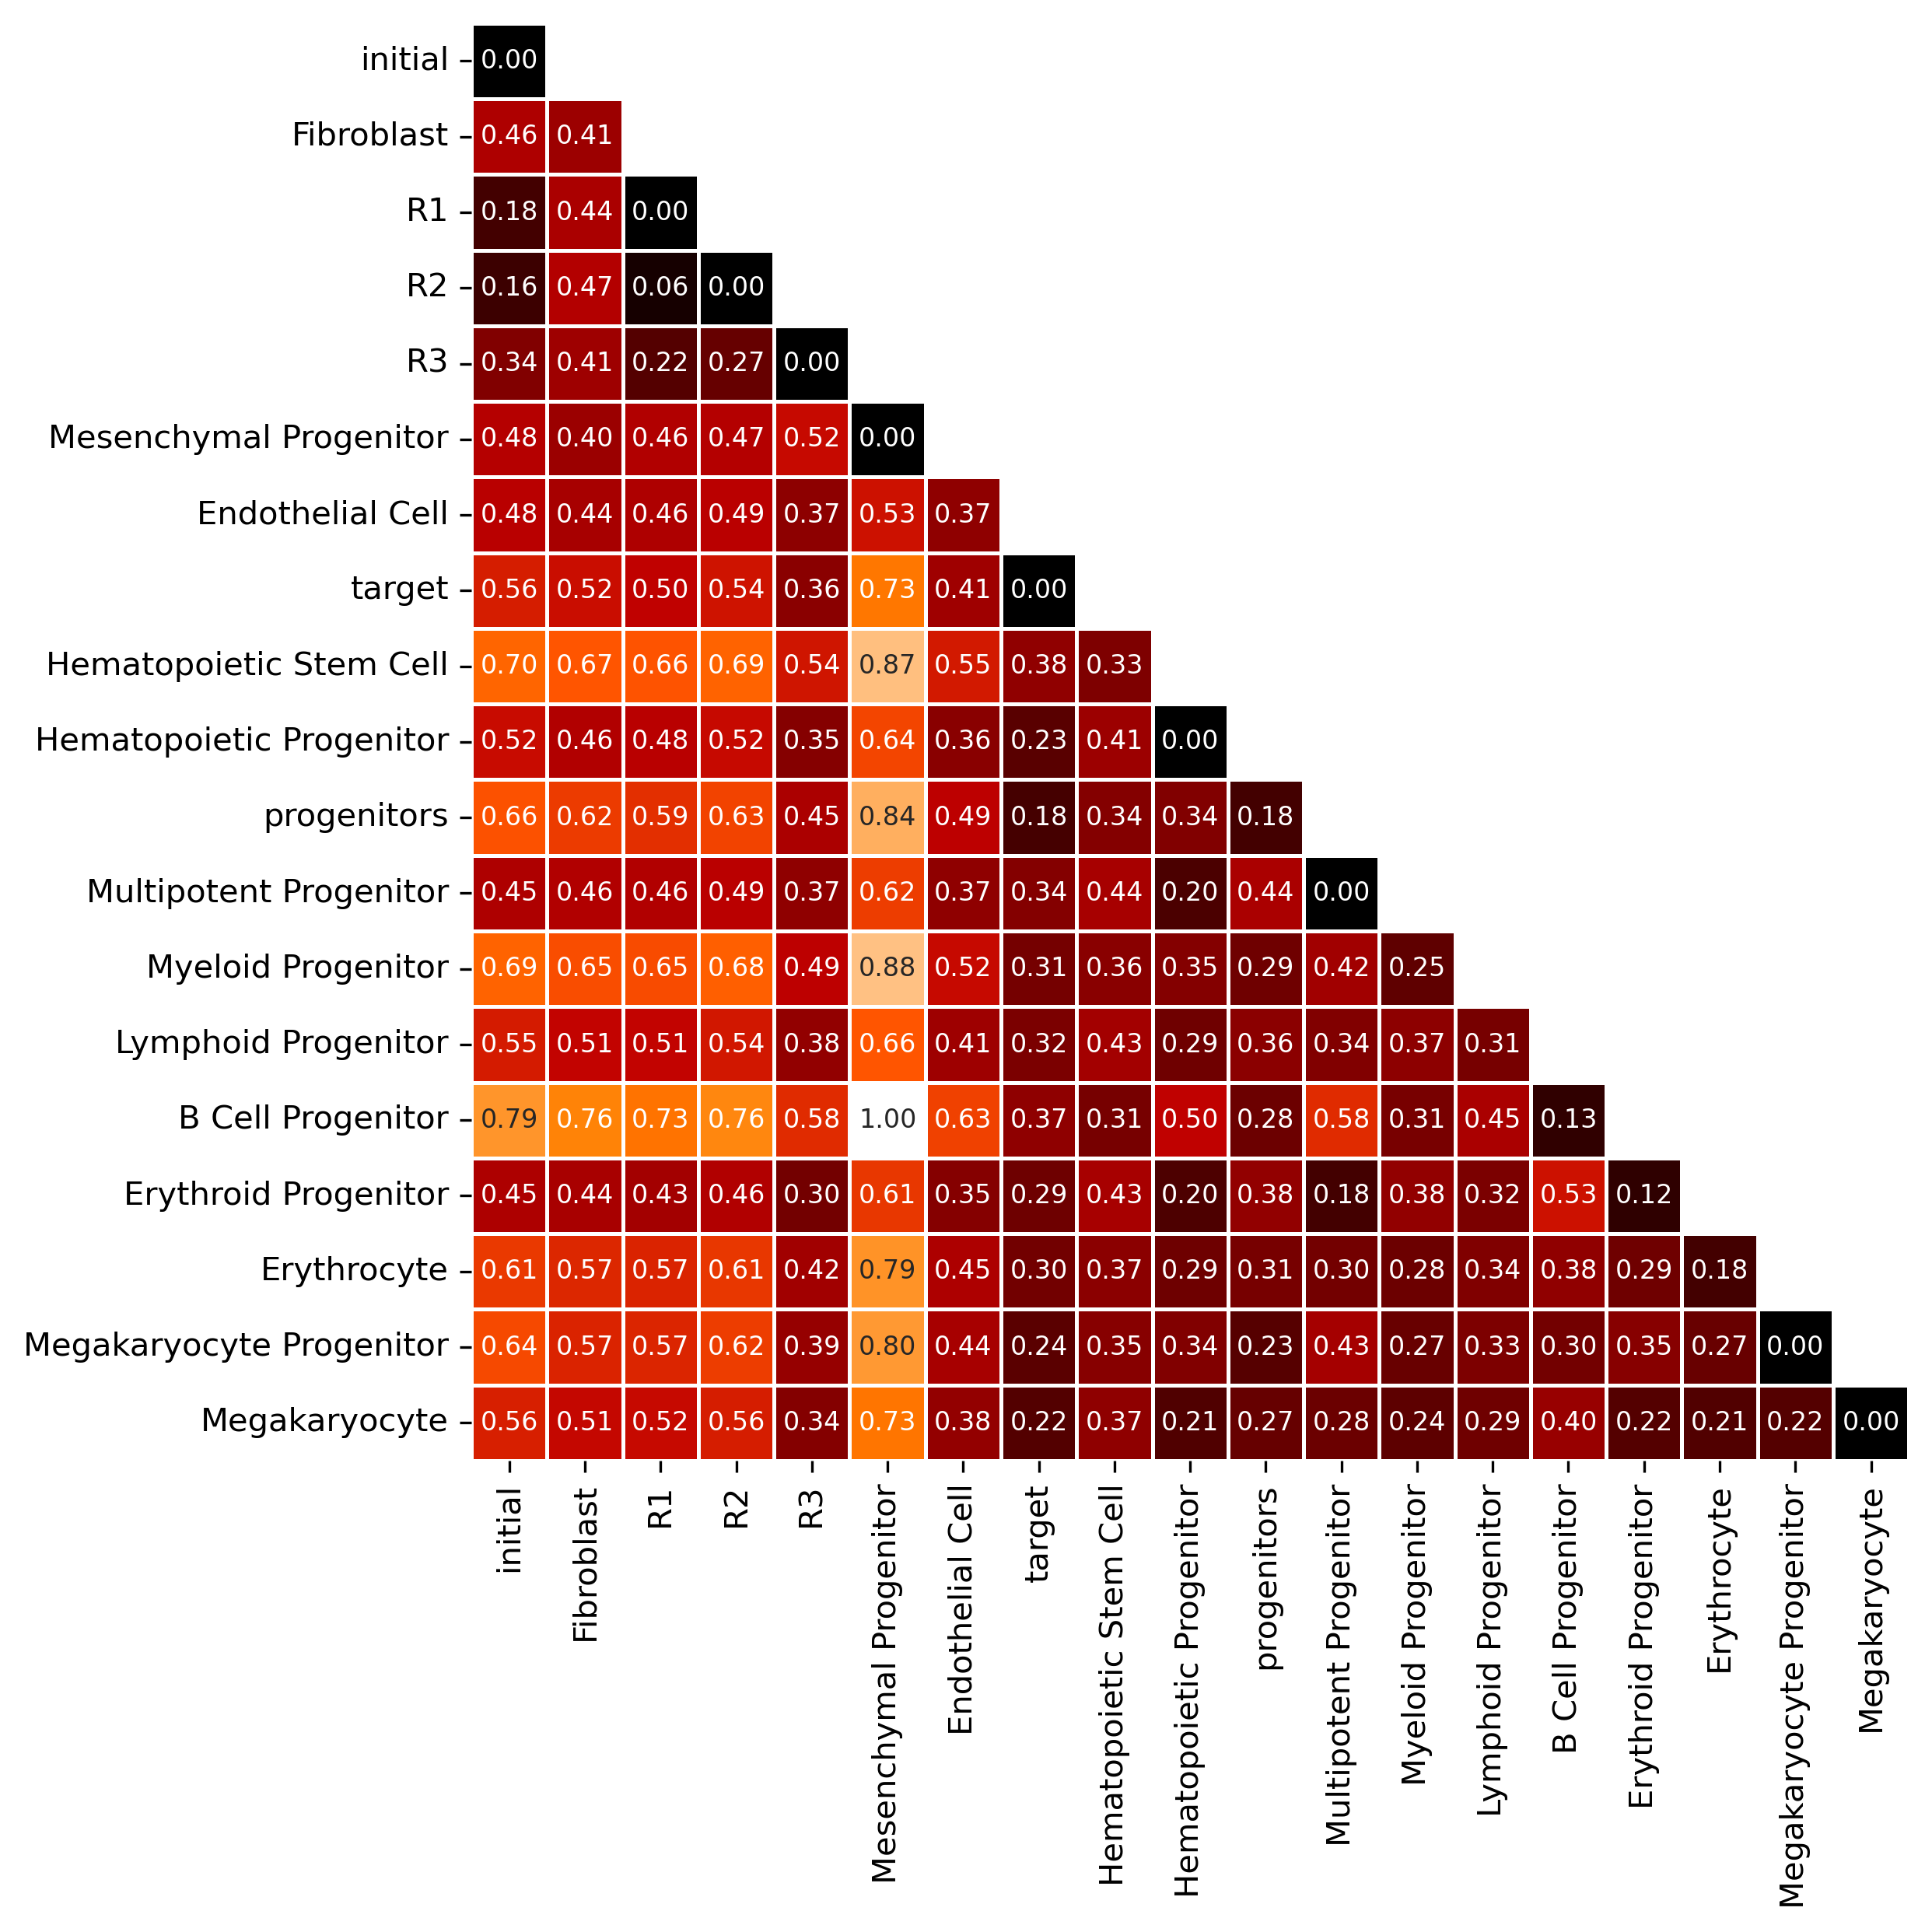

In [46]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 8, 8

# order = [
#     'intial', 
#     'fibroblast',
#     'reprogram', 
#     'endothelial cell', 
#     'target',
#     'hematopoietic stem cell',
#     'lymphoid progenitor',  
#     'myeloid progenitor',
#     'erythroid progenitor',
#     'erythrocyte',
#     'b cell progenitor',
#     'multipotent progenitor',
#     'hematopoietic progenitor',
#     'bm other',     
# ]

order = [
    'initial',
    'Fibroblast',   
    'R1', 'R2', 'R3',    
    'Mesenchymal Progenitor',
    # 'Mesenchymal Stem Cell',
    'Endothelial Cell',   
    'target',#'HSC',
    'Hematopoietic Stem Cell',
    'Hematopoietic Progenitor',
    'progenitors',
    'Multipotent Progenitor',
    # 'MPP',
    # 'CMP',
    'Myeloid Progenitor',
    # 'GMP', 
    'Lymphoid Progenitor',
    # 'LMPP',
    # 'CLP',
    'B Cell Progenitor',
    'Erythroid Progenitor',
    'Erythrocyte',
    # 'MEG-ERY',
    'Megakaryocyte Progenitor',
    'Megakaryocyte',
]

pdf = df.copy()

# establish sort order
pdf = pdf[order].reindex(order)
mask = np.triu(np.ones_like(pdf, dtype=bool), k=1)

sns.heatmap(
    pdf, square=True,
    mask=mask,
    cmap='gist_heat',
    linewidth=0.75,
    annot=True,
    fmt=".2f",
    annot_kws={'fontsize' : 8},
    cbar=False,
    vmin=0, 
    vmax=1,
)

# plt.xticks([])
plt.xlabel("")
plt.ylabel("")